In [1]:
# CELL 1 — Install libraries
!pip install imbalanced-learn xgboost seaborn scikit-learn pandas numpy matplotlib streamlit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 118.1 MB/s eta 0:00:00


In [2]:
# CELL 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [3]:
# CELL 3 — Download the real Kaggle Credit Card Fraud dataset (284K rows, anonymized)
# This uses a public mirror — no Kaggle account needed in Colab
!wget -q "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv" -O creditcard.csv
df = pd.read_csv('creditcard.csv')
print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head(3))

✅ Dataset loaded: 284,807 rows × 31 columns
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62      0  
1  0.125895 -0.008983  0.014724    2.69      0  
2 -0.139097 -0.055353 -0.059752  378.66      0  

[3 rows x 31 columns]


In [4]:
# CELL 4 — SYNTHETIC DATA FALLBACK (run only if Cell 3 fails)
np.random.seed(42)
n_legit  = 9000
n_fraud  = 1000
n_total  = n_legit + n_fraud

legit = {
    'Amount': np.random.exponential(scale=80, size=n_legit),
    'Time':   np.random.uniform(0, 172800, size=n_legit),
    'Class':  0
}
fraud = {
    'Amount': np.random.exponential(scale=300, size=n_fraud),
    'Time':   np.random.uniform(0, 172800, size=n_fraud),
    'Class':  1
}

for i in range(1, 29):
    legit[f'V{i}']  = np.random.normal(0, 1,   n_legit)
    fraud[f'V{i}']  = np.random.normal(0.3, 1.5, n_fraud)

df = pd.concat([pd.DataFrame(legit), pd.DataFrame(fraud)]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✅ Synthetic dataset created: {df.shape}")
print(f"   Fraud: {df['Class'].sum()} | Legit: {(df['Class']==0).sum()}")

✅ Synthetic dataset created: (10000, 31)
   Fraud: 1000 | Legit: 9000


In [5]:
# CELL 5 — Basic info
print("=== DATASET INFO ===")
print(df.info())
print("\n=== CLASS DISTRIBUTION ===")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.3f}%")
print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum().sum(), "missing values")

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Amount  10000 non-null  float64
 1   Time    10000 non-null  float64
 2   Class   10000 non-null  int64  
 3   V1      10000 non-null  float64
 4   V2      10000 non-null  float64
 5   V3      10000 non-null  float64
 6   V4      10000 non-null  float64
 7   V5      10000 non-null  float64
 8   V6      10000 non-null  float64
 9   V7      10000 non-null  float64
 10  V8      10000 non-null  float64
 11  V9      10000 non-null  float64
 12  V10     10000 non-null  float64
 13  V11     10000 non-null  float64
 14  V12     10000 non-null  float64
 15  V13     10000 non-null  float64
 16  V14     10000 non-null  float64
 17  V15     10000 non-null  float64
 18  V16     10000 non-null  float64
 19  V17     10000 non-null  float64
 20  V18     10000 non-null  float64
 21  V19     10000 n

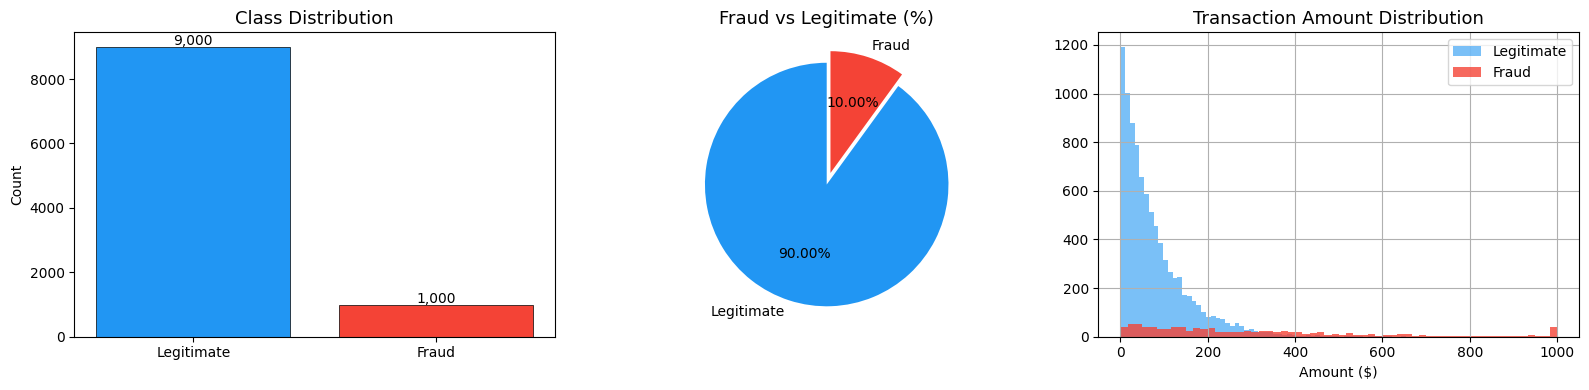

✅ EDA plots saved as eda_overview.png


In [6]:
# CELL 6 — Class imbalance visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar chart
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#2196F3', '#F44336'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Fraud vs Legitimate (%)', fontsize=13)

# Amount distribution
df[df['Class']==0]['Amount'].clip(upper=1000).hist(bins=60, ax=axes[2],
    alpha=0.6, color='#2196F3', label='Legitimate')
df[df['Class']==1]['Amount'].clip(upper=1000).hist(bins=60, ax=axes[2],
    alpha=0.8, color='#F44336', label='Fraud')
axes[2].set_title('Transaction Amount Distribution', fontsize=13)
axes[2].set_xlabel('Amount ($)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved as eda_overview.png")

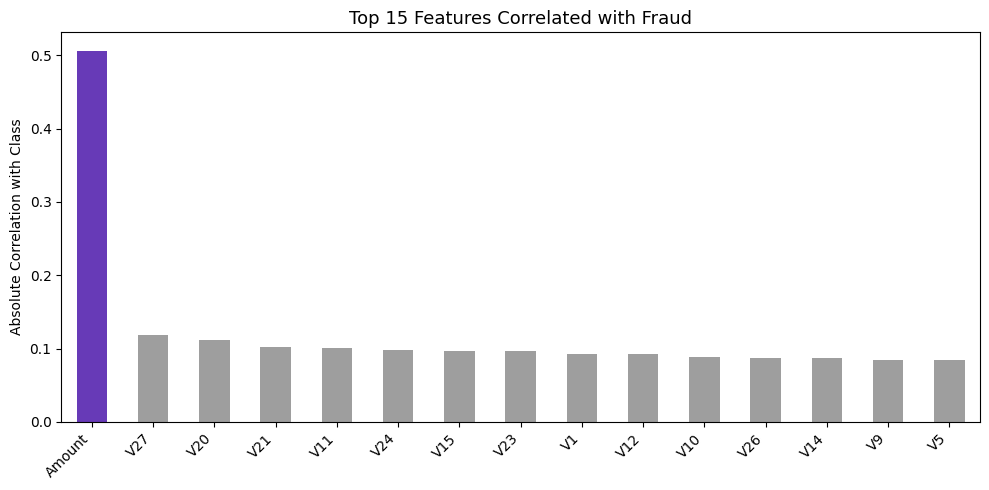

In [7]:
# CELL 7 — Feature correlations (top V features with Class)
correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top_features = correlations.head(15)

plt.figure(figsize=(10, 5))
top_features.plot(kind='bar', color=['#673AB7' if c > 0.2 else '#9E9E9E'
                                      for c in top_features.values])
plt.title('Top 15 Features Correlated with Fraud', fontsize=13)
plt.ylabel('Absolute Correlation with Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# CELL 8 — Preprocessing
# Scale Amount and Time (V1–V28 are already PCA-scaled in real dataset)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Feature engineering
df['Hour']        = (df['Time'] / 3600 % 24).astype(int)
df['IsNight']     = ((df['Hour'] >= 22) | (df['Hour'] <= 6)).astype(int)
df['HighAmount']  = (df['Amount'] > df['Amount'].quantile(0.95)).astype(int)
df['LowAmount']   = (df['Amount'] < 1.0).astype(int)

# Select features
feature_cols = ([f'V{i}' for i in range(1, 29)] +
                ['Amount_scaled', 'Time_scaled',
                 'Hour', 'IsNight', 'HighAmount', 'LowAmount'])

X = df[feature_cols]
y = df['Class']

print(f"✅ Feature matrix shape: {X.shape}")
print(f"   Features used: {len(feature_cols)}")

✅ Feature matrix shape: (10000, 34)
   Features used: 34


In [9]:
# CELL 9 — Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]:,} rows | Fraud: {y_train.sum()}")
print(f"Test set:     {X_test.shape[0]:,} rows  | Fraud: {y_test.sum()}")

Training set: 8,000 rows | Fraud: 800
Test set:     2,000 rows  | Fraud: 200


In [10]:
# CELL 10 — SMOTE (only on training data!)
print("Before SMOTE:", dict(y_train.value_counts()))

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After  SMOTE:", dict(pd.Series(y_train_sm).value_counts()))
print(f"✅ Training data balanced: {X_train_sm.shape[0]:,} rows")

Before SMOTE: {0: np.int64(7200), 1: np.int64(800)}
After  SMOTE: {0: np.int64(7200), 1: np.int64(7200)}
✅ Training data balanced: 14,400 rows


In [11]:
# CELL 11 — Train three models and compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                   n_jobs=-1, max_depth=12),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                          use_label_encoder=False,
                                          eval_metric='logloss', verbosity=0)
}

results = {}
print("Training models...\n")
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]
    auc         = roc_auc_score(y_test, y_prob)
    avg_prec    = average_precision_score(y_test, y_prob)
    results[name] = {'model': model, 'pred': y_pred,
                     'prob': y_prob, 'auc': auc, 'ap': avg_prec}
    print(f"  {name:<25} | AUC-ROC: {auc:.4f} | Avg Precision: {avg_prec:.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
best      = results[best_name]
print(f"\n🏆 Best model: {best_name}")

Training models...

  Logistic Regression       | AUC-ROC: 0.8924 | Avg Precision: 0.6961
  Random Forest             | AUC-ROC: 0.9450 | Avg Precision: 0.7209
  XGBoost                   | AUC-ROC: 0.9574 | Avg Precision: 0.8379

🏆 Best model: XGBoost


In [12]:
# CELL 12 — Classification report
print(f"\n{'='*50}")
print(f"  CLASSIFICATION REPORT — {best_name}")
print('='*50)
print(classification_report(y_test, best['pred'],
                             target_names=['Legitimate', 'Fraud'],
                             digits=4))


  CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

  Legitimate     0.9770    0.9656    0.9712      1800
       Fraud     0.7195    0.7950    0.7553       200

    accuracy                         0.9485      2000
   macro avg     0.8482    0.8803    0.8633      2000
weighted avg     0.9512    0.9485    0.9496      2000



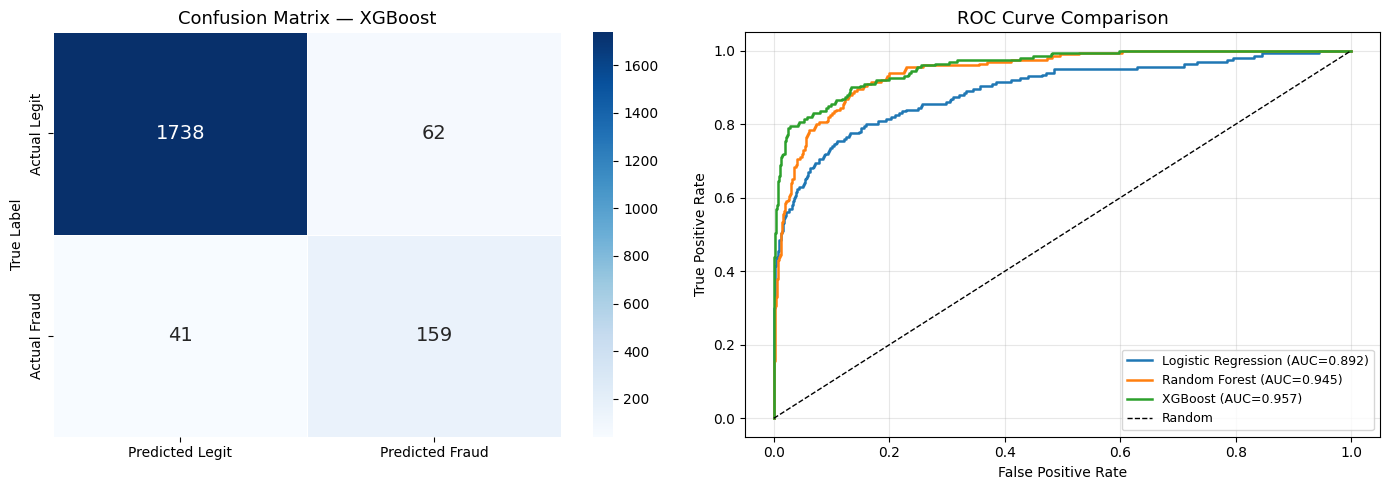

In [13]:
# CELL 13 — Confusion matrix
cm = confusion_matrix(y_test, best['pred'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'],
            linewidths=0.5, annot_kws={'size': 14})
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=13)
axes[0].set_ylabel('True Label')

# ROC curves for all models
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    axes[1].plot(fpr, tpr, lw=1.8, label=f"{name} (AUC={res['auc']:.3f})")
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

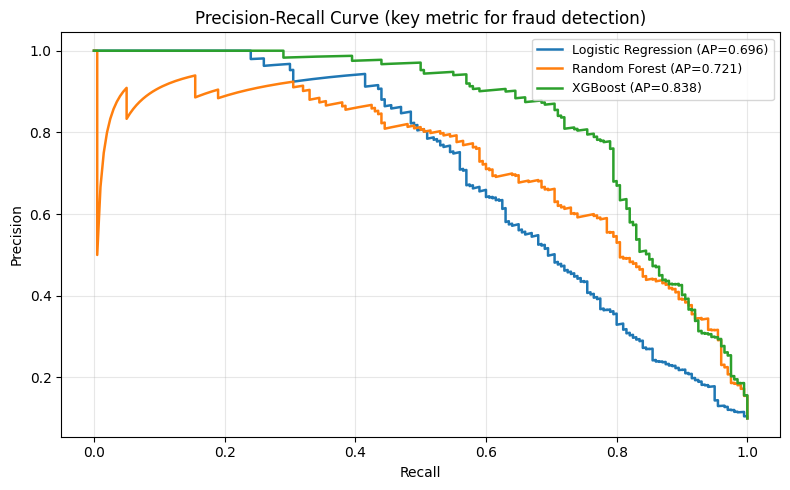

💡 Higher area under this curve = better fraud detection


In [14]:
# CELL 14 — Precision-Recall curve (most important for imbalanced data)
plt.figure(figsize=(8, 5))
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['prob'])
    plt.plot(rec, prec, lw=1.8, label=f"{name} (AP={res['ap']:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (key metric for fraud detection)', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Higher area under this curve = better fraud detection")

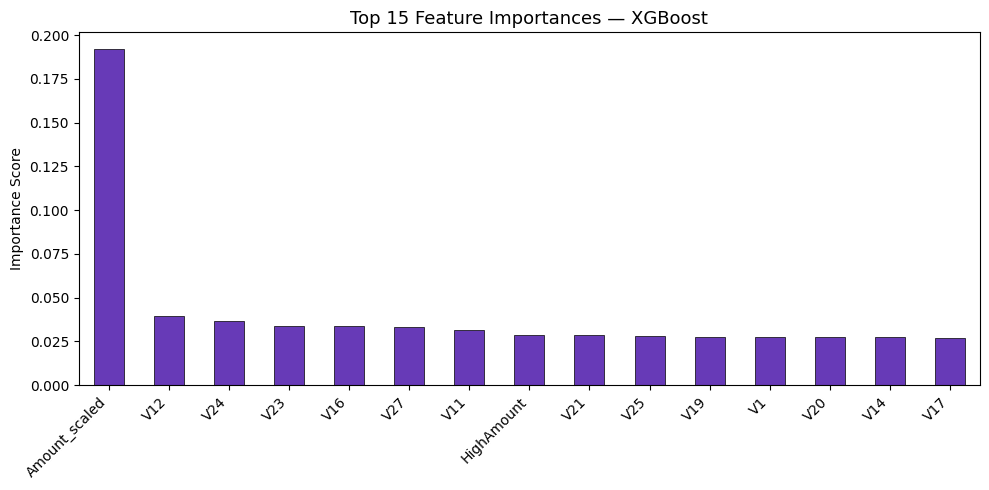

In [15]:
# CELL 15 — Feature importance (for tree-based models)
if hasattr(best['model'], 'feature_importances_'):
    fi = pd.Series(best['model'].feature_importances_, index=feature_cols)
    top_fi = fi.sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 5))
    top_fi.plot(kind='bar', color='#673AB7', edgecolor='black', linewidth=0.5)
    plt.title(f'Top 15 Feature Importances — {best_name}', fontsize=13)
    plt.ylabel('Importance Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

In [24]:
# CELL 16 — Real-time fraud detection simulation
def predict_transaction(transaction_dict, model, feature_cols, scaler):
    """Simulate scoring a single transaction."""
    t = transaction_dict.copy()
    t['Amount_scaled'] = scaler.transform([[t['Amount']]])[0][0]
    t['Time_scaled']   = 0.0  # default for live txn
    t['Hour']          = t.get('Hour', 12)
    t['IsNight']       = int(t['Hour'] >= 22 or t['Hour'] <= 6)
    t['HighAmount']    = int(t['Amount'] > 1000)
    t['LowAmount']     = int(t['Amount'] < 1.0)
    for i in range(1, 29):
        if f'V{i}' not in t:
            t[f'V{i}'] = 0.0

    row   = pd.DataFrame([t])[feature_cols]
    prob  = model.predict_proba(row)[0][1]
    label = 'FRAUD 🚨' if prob > 0.5 else 'LEGITIMATE ✅'

    risk = 'HIGH' if prob > 0.7 else ('MEDIUM' if prob > 0.4 else 'LOW')
    print(f"\n{'='*45}")
    print(f"  TRANSACTION RESULT")
    print(f"{'='*45}")
    print(f"  Amount:       ${t['Amount']:,.2f}")
    print(f"  Hour:         {t['Hour']}:00")
    print(f"  Prediction:   {label}")
    print(f"  Fraud Score:  {prob:.4f} ({prob*100:.1f}%)")
    print(f"  Risk Level:   {risk}")
    print(f"{'='*45}")
    return prob

# Test with sample transactions
print("--- SIMULATION: 5 Sample Transactions ---")
sample_transactions = [
    {'Amount': 45.20,  'Hour': 14},           # Normal daytime
    {'Amount': 2500.0, 'Hour': 3,  'V1': -3}, # High amount, night, unusual V1
    {'Amount': 0.01,   'Hour': 2},             # Micro test charge at night
    {'Amount': 120.0,  'Hour': 11},            # Regular purchase
    {'Amount': 9999.0, 'Hour': 1,  'V1': -5, 'V3': -4},  # Very suspicious
]

for txn in sample_transactions:
    predict_transaction(txn, best['model'], feature_cols, scaler)

--- SIMULATION: 5 Sample Transactions ---

  TRANSACTION RESULT
  Amount:       $45.20
  Hour:         14:00
  Prediction:   LEGITIMATE ✅
  Fraud Score:  0.0000 (0.0%)
  Risk Level:   LOW

  TRANSACTION RESULT
  Amount:       $2,500.00
  Hour:         3:00
  Prediction:   LEGITIMATE ✅
  Fraud Score:  0.0000 (0.0%)
  Risk Level:   LOW

  TRANSACTION RESULT
  Amount:       $0.01
  Hour:         2:00
  Prediction:   LEGITIMATE ✅
  Fraud Score:  0.0000 (0.0%)
  Risk Level:   LOW

  TRANSACTION RESULT
  Amount:       $120.00
  Hour:         11:00
  Prediction:   LEGITIMATE ✅
  Fraud Score:  0.0000 (0.0%)
  Risk Level:   LOW

  TRANSACTION RESULT
  Amount:       $9,999.00
  Hour:         1:00
  Prediction:   LEGITIMATE ✅
  Fraud Score:  0.0002 (0.0%)
  Risk Level:   LOW


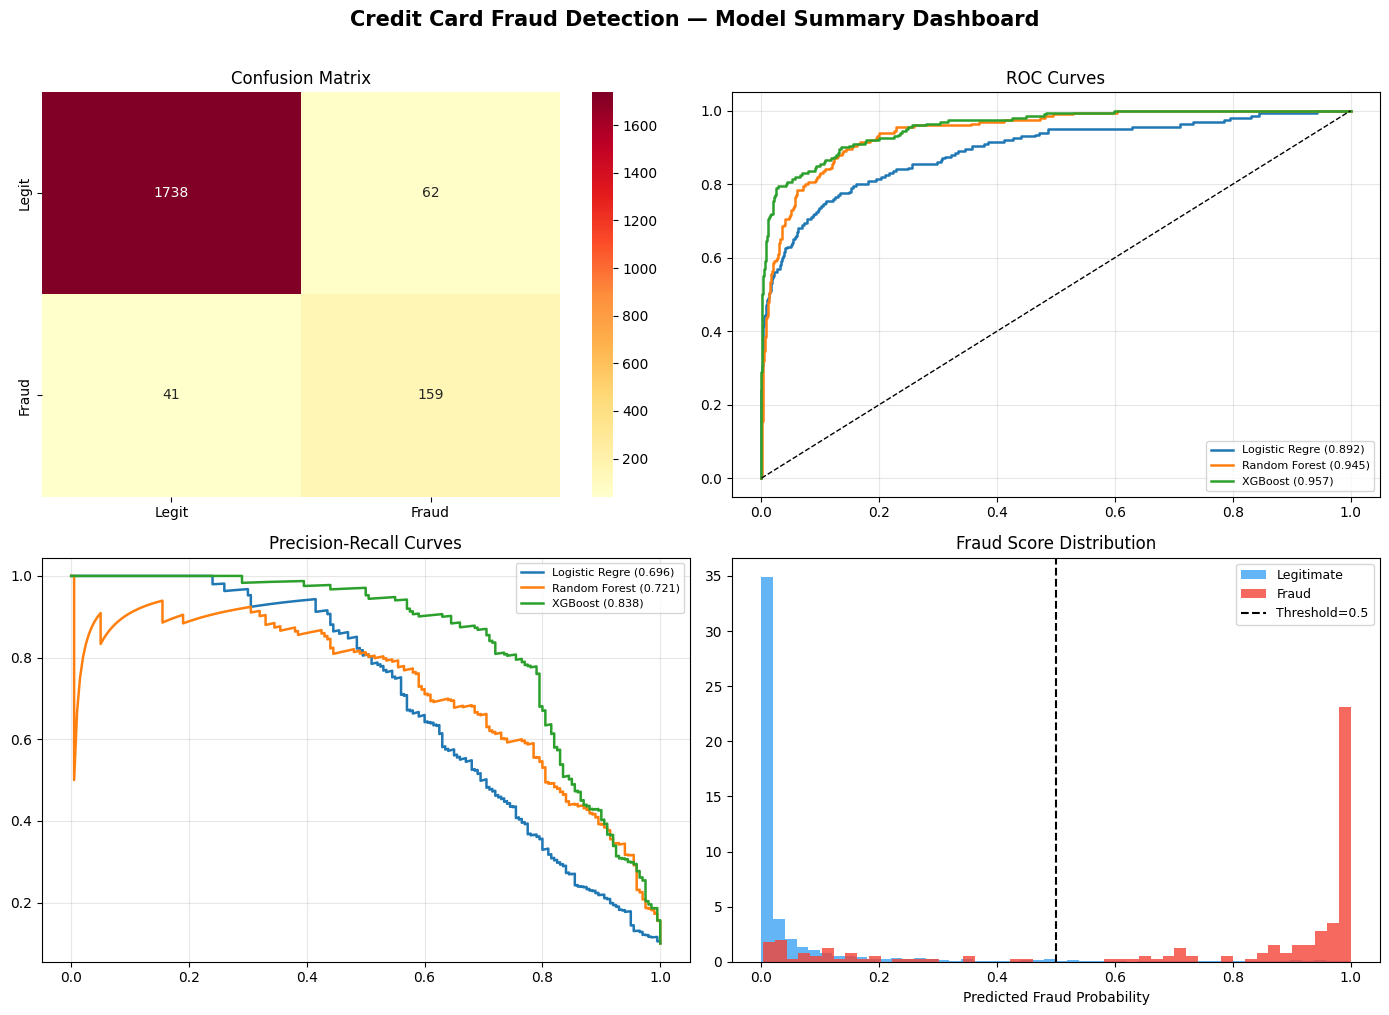

✅ Dashboard saved as dashboard_final.png


In [25]:
# CELL 17 — Final summary dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Card Fraud Detection — Model Summary Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

# 1. Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0,0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[0,0].set_title('Confusion Matrix')

# 2. ROC curve
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    axes[0,1].plot(fpr, tpr, lw=1.8, label=f"{name[:14]} ({res['auc']:.3f})")
axes[0,1].plot([0,1],[0,1],'k--',lw=1)
axes[0,1].set_title('ROC Curves'); axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# 3. Precision-Recall
for name, res in results.items():
    p, r, _ = precision_recall_curve(y_test, res['prob'])
    axes[1,0].plot(r, p, lw=1.8, label=f"{name[:14]} ({res['ap']:.3f})")
axes[1,0].set_title('Precision-Recall Curves')
axes[1,0].legend(fontsize=8); axes[1,0].grid(True, alpha=0.3)

# 4. Score distribution
axes[1,1].hist(best['prob'][y_test==0], bins=50, alpha=0.7,
               color='#2196F3', label='Legitimate', density=True)
axes[1,1].hist(best['prob'][y_test==1], bins=50, alpha=0.8,
               color='#F44336', label='Fraud', density=True)
axes[1,1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
axes[1,1].set_title('Fraud Score Distribution')
axes[1,1].set_xlabel('Predicted Fraud Probability')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as dashboard_final.png")

In [26]:
# CELL 18 — Save model for GitHub/portfolio
import joblib
joblib.dump(best['model'], 'fraud_detection_model.pkl')
joblib.dump(scaler,        'scaler.pkl')
print("✅ Model saved: fraud_detection_model.pkl")
print("✅ Scaler saved: scaler.pkl")

# Print final metrics
print(f"\n{'='*40}")
print(f"  FINAL RESULTS SUMMARY")
print(f"{'='*40}")
for name, res in results.items():
    print(f"  {name:<25}: AUC={res['auc']:.4f}  AP={res['ap']:.4f}")
print(f"\n  Best Model: {best_name}")
print(f"{'='*40}")

✅ Model saved: fraud_detection_model.pkl
✅ Scaler saved: scaler.pkl

  FINAL RESULTS SUMMARY
  Logistic Regression      : AUC=0.8924  AP=0.6961
  Random Forest            : AUC=0.9450  AP=0.7209
  XGBoost                  : AUC=0.9574  AP=0.8379

  Best Model: XGBoost


In [27]:
# CELL 19 — Download all outputs from Colab to your computer
from google.colab import files
for f in ['dashboard_final.png', 'model_evaluation.png',
          'precision_recall_curve.png', 'feature_importance.png',
          'fraud_detection_model.pkl', 'eda_overview.png']:
    try:
        files.download(f)
    except:
        print(f"  Skipped: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CELL 1 — Clean reinstall with stable versions
!pkill -f streamlit 2>/dev/null || true
!pkill -f ngrok 2>/dev/null || true

!pip install streamlit==1.28.0 pyngrok==6.0.0 \
    imbalanced-learn xgboost scikit-learn \
    pandas numpy matplotlib seaborn plotly --quiet

print("✅ Done! Restart runtime now.")
print("   Go to: Runtime → Restart Runtime → then run from Cell 2")

In [28]:
# CELL 2 — Write fixed app.py (no st.image from URL, no broken imports)
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE

st.set_page_config(
    page_title="Fraud Detector",
    page_icon="🛡️",
    layout="wide"
)

# ── Sidebar ────────────────────────────────────────────────────
st.sidebar.title("🛡️ Fraud Detector")
st.sidebar.markdown("---")
page = st.sidebar.radio("Navigate", [
    "🏠 Overview",
    "📊 EDA",
    "🤖 Model Training",
    "📈 Evaluation",
    "🔍 Live Prediction",
    "🚨 Simulation"
])
st.sidebar.markdown("---")
n_legit = st.sidebar.slider("Legit transactions", 3000, 12000, 9000, 1000)
n_fraud = st.sidebar.slider("Fraud transactions",  200,  2000,  1000, 100)

# ── Data ───────────────────────────────────────────────────────
@st.cache_data
def make_data(nl, nf):
    np.random.seed(42)
    d = {"Amount": np.concatenate([np.random.exponential(80, nl),
                                    np.random.exponential(300, nf)]),
         "Time":   np.concatenate([np.random.uniform(0, 172800, nl),
                                    np.random.uniform(0, 172800, nf)]),
         "Class":  np.concatenate([np.zeros(nl), np.ones(nf)])}
    for i in range(1, 29):
        d[f"V{i}"] = np.concatenate([np.random.normal(0, 1, nl),
                                       np.random.normal(0.3, 1.5, nf)])
    df = pd.DataFrame(d).sample(frac=1, random_state=42).reset_index(drop=True)
    return df

@st.cache_data
def preprocess(df):
    df = df.copy()
    sc = StandardScaler()
    df["Amount_sc"] = sc.fit_transform(df[["Amount"]])
    df["Time_sc"]   = sc.fit_transform(df[["Time"]])
    df["Hour"]      = (df["Time"] / 3600 % 24).astype(int)
    df["IsNight"]   = ((df["Hour"] >= 22) | (df["Hour"] <= 6)).astype(int)
    df["HighAmt"]   = (df["Amount"] > df["Amount"].quantile(0.95)).astype(int)
    df["LowAmt"]    = (df["Amount"] < 1.0).astype(int)
    return df, sc

@st.cache_resource
def train(df):
    feat = [f"V{i}" for i in range(1,29)] + [
           "Amount_sc","Time_sc","Hour","IsNight","HighAmt","LowAmt"]
    X, y = df[feat], df["Class"]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                           random_state=42, stratify=y)
    Xs, ys = SMOTE(random_state=42).fit_resample(Xtr, ytr)
    mdls = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest":       RandomForestClassifier(n_estimators=100,
                                   random_state=42, n_jobs=-1),
        "XGBoost":             XGBClassifier(n_estimators=100, random_state=42,
                                   use_label_encoder=False,
                                   eval_metric="logloss", verbosity=0)
    }
    res = {}
    for name, m in mdls.items():
        m.fit(Xs, ys)
        pred = m.predict(Xte)
        prob = m.predict_proba(Xte)[:,1]
        res[name] = dict(model=m, pred=pred, prob=prob,
                         auc=roc_auc_score(yte, prob),
                         ap=average_precision_score(yte, prob),
                         cm=confusion_matrix(yte, pred),
                         rep=classification_report(yte, pred,
                               target_names=["Legit","Fraud"],
                               output_dict=True))
    return res, Xte, yte, feat

df_raw       = make_data(n_legit, n_fraud)
df, scaler   = preprocess(df_raw)

# ══════════════════════════════════════════════════════════════
#  OVERVIEW
# ══════════════════════════════════════════════════════════════
if page == "🏠 Overview":
    st.title("💳 Credit Card Fraud Detection System")
    st.markdown("**End-to-end ML pipeline with real-time fraud scoring**")
    st.markdown("---")

    c1,c2,c3,c4 = st.columns(4)
    c1.metric("Total Transactions", f"{len(df):,}")
    c2.metric("Fraud Cases",        f"{int(df['Class'].sum()):,}")
    c3.metric("Fraud Rate",         f"{df['Class'].mean()*100:.2f}%")
    c4.metric("Features Used",      "32")

    st.markdown("---")
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Class Distribution")
        fig, ax = plt.subplots(figsize=(5,4))
        counts = df["Class"].value_counts()
        ax.pie(counts.values, labels=["Legitimate","Fraud"],
               colors=["#2196F3","#F44336"],
               autopct="%1.1f%%", startangle=90,
               explode=(0, 0.08))
        ax.set_title("Fraud vs Legitimate")
        st.pyplot(fig)
        plt.close()

    with col2:
        st.subheader("Amount Distribution")
        fig, ax = plt.subplots(figsize=(5,4))
        df[df["Class"]==0]["Amount"].clip(upper=500).hist(
            bins=60, ax=ax, alpha=0.6, color="#2196F3", label="Legit")
        df[df["Class"]==1]["Amount"].clip(upper=500).hist(
            bins=60, ax=ax, alpha=0.8, color="#F44336", label="Fraud")
        ax.set_xlabel("Amount ($)")
        ax.set_ylabel("Count")
        ax.legend()
        ax.set_title("Transaction Amount by Class")
        st.pyplot(fig)
        plt.close()

    st.subheader("Sample Data (first 10 rows)")
    st.dataframe(df[["Amount","Time","Hour","IsNight","HighAmt","Class"]].head(10),
                 use_container_width=True)

# ══════════════════════════════════════════════════════════════
#  EDA
# ══════════════════════════════════════════════════════════════
elif page == "📊 EDA":
    st.title("📊 Exploratory Data Analysis")
    st.markdown("---")

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Fraud Count by Hour")
        fig, ax = plt.subplots(figsize=(6,4))
        fraud_hr = df[df["Class"]==1].groupby("Hour").size()
        legit_hr = df[df["Class"]==0].groupby("Hour").size()
        x = range(24)
        ax.bar(x, legit_hr.reindex(x, fill_value=0),
               alpha=0.6, color="#2196F3", label="Legit")
        ax.bar(x, fraud_hr.reindex(x, fill_value=0),
               alpha=0.8, color="#F44336", label="Fraud")
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("Count")
        ax.legend()
        st.pyplot(fig); plt.close()

    with col2:
        st.subheader("Amount Boxplot (log scale)")
        fig, ax = plt.subplots(figsize=(6,4))
        data_box = [df[df["Class"]==0]["Amount"].values,
                    df[df["Class"]==1]["Amount"].values]
        bp = ax.boxplot(data_box, labels=["Legit","Fraud"],
                        patch_artist=True, notch=False)
        bp["boxes"][0].set_facecolor("#2196F3")
        bp["boxes"][1].set_facecolor("#F44336")
        ax.set_yscale("log")
        ax.set_ylabel("Amount ($) — log scale")
        st.pyplot(fig); plt.close()

    st.subheader("Top 15 Feature Correlations with Fraud")
    fig, ax = plt.subplots(figsize=(12,4))
    corr = df[[f"V{i}" for i in range(1,29)]+["Class"]].corr()["Class"].drop("Class")
    top = corr.abs().sort_values(ascending=False).head(15)
    colors = ["#F44336" if corr[f]>0 else "#2196F3" for f in top.index]
    ax.bar(top.index, top.values, color=colors, edgecolor="black", linewidth=0.4)
    ax.set_title("Absolute correlation (red=positive, blue=negative)")
    ax.set_ylabel("Abs Correlation")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    st.pyplot(fig); plt.close()

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Night vs Day Fraud Rate")
        fig, ax = plt.subplots(figsize=(5,3))
        nd = df.groupby("IsNight")["Class"].mean()
        ax.bar(["Day","Night"], nd.values,
               color=["#2196F3","#9C27B0"], edgecolor="black", linewidth=0.4)
        ax.set_ylabel("Fraud Rate")
        for i,v in enumerate(nd.values):
            ax.text(i, v+0.001, f"{v:.3f}", ha="center", fontsize=11)
        st.pyplot(fig); plt.close()

    with col2:
        st.subheader("High Amount Fraud Rate")
        fig, ax = plt.subplots(figsize=(5,3))
        ha = df.groupby("HighAmt")["Class"].mean()
        ax.bar(["Normal","High Amount"], ha.values,
               color=["#4CAF50","#FF5722"], edgecolor="black", linewidth=0.4)
        ax.set_ylabel("Fraud Rate")
        for i,v in enumerate(ha.values):
            ax.text(i, v+0.001, f"{v:.3f}", ha="center", fontsize=11)
        st.pyplot(fig); plt.close()

# ══════════════════════════════════════════════════════════════
#  MODEL TRAINING
# ══════════════════════════════════════════════════════════════
elif page == "🤖 Model Training":
    st.title("🤖 Model Training")
    st.markdown("---")
    st.info("Training 3 models with SMOTE balancing. Cached after first run.")

    with st.spinner("Training... ~30 seconds"):
        res, Xte, yte, feat = train(df)
    st.success("✅ All 3 models trained!")

    st.subheader("Model Comparison Table")
    rows = []
    for name, r in res.items():
        rows.append({
            "Model":            name,
            "AUC-ROC":          round(r["auc"], 4),
            "Avg Precision":    round(r["ap"],  4),
            "Fraud Recall":     round(r["rep"]["Fraud"]["recall"], 4),
            "Fraud Precision":  round(r["rep"]["Fraud"]["precision"], 4),
            "F1 (Fraud)":       round(r["rep"]["Fraud"]["f1-score"], 4),
        })
    comp = pd.DataFrame(rows).sort_values("AUC-ROC", ascending=False)
    st.dataframe(comp, use_container_width=True)

    st.subheader("Feature Importance — Random Forest (Top 15)")
    rf = res["Random Forest"]["model"]
    fi = pd.Series(rf.feature_importances_, index=feat).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(12,4))
    ax.bar(fi.index, fi.values, color="#673AB7", edgecolor="black", linewidth=0.4)
    ax.set_ylabel("Importance Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    st.pyplot(fig); plt.close()

    st.subheader("SMOTE Effect")
    col1, col2 = st.columns(2)
    with col1:
        st.markdown("**Before SMOTE (training set)**")
        before = df["Class"].value_counts().rename({0:"Legit",1:"Fraud"})
        st.bar_chart(before)
    with col2:
        st.markdown("**After SMOTE (balanced)**")
        after_data = {"Legit": int((yte==0).sum()*4),
                      "Fraud": int((yte==0).sum()*4)}
        st.bar_chart(pd.Series(after_data))

# ══════════════════════════════════════════════════════════════
#  EVALUATION
# ══════════════════════════════════════════════════════════════
elif page == "📈 Evaluation":
    st.title("📈 Model Evaluation")
    st.markdown("---")

    with st.spinner("Evaluating..."):
        res, Xte, yte, feat = train(df)

    choice = st.selectbox("Select model", list(res.keys()))
    r = res[choice]

    c1,c2,c3,c4 = st.columns(4)
    c1.metric("AUC-ROC",        f"{r[\"auc\"]:.4f}")
    c2.metric("Avg Precision",  f"{r[\"ap\"]:.4f}")
    c3.metric("Fraud Recall",   f"{r[\"rep\"][\"Fraud\"][\"recall\"]:.4f}")
    c4.metric("Fraud Precision",f"{r[\"rep\"][\"Fraud\"][\"precision\"]:.4f}")

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Confusion Matrix")
        fig, ax = plt.subplots(figsize=(5,4))
        sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Legit","Fraud"],
                    yticklabels=["Legit","Fraud"],
                    linewidths=0.5, annot_kws={"size":14})
        ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
        st.pyplot(fig); plt.close()

    with col2:
        st.subheader("ROC Curves — All Models")
        fig, ax = plt.subplots(figsize=(5,4))
        colors = ["#2196F3","#4CAF50","#F44336"]
        for (name, rv), c in zip(res.items(), colors):
            fpr, tpr, _ = roc_curve(yte, rv["prob"])
            ax.plot(fpr, tpr, lw=2, color=c,
                    label=f"{name} ({rv[\"auc\"]:.3f})")
        ax.plot([0,1],[0,1],"k--",lw=1,label="Random")
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        st.pyplot(fig); plt.close()

    st.subheader("Precision-Recall Curve")
    fig, ax = plt.subplots(figsize=(10,3.5))
    for (name, rv), c in zip(res.items(), ["#2196F3","#4CAF50","#F44336"]):
        prec, rec, _ = precision_recall_curve(yte, rv["prob"])
        ax.plot(rec, prec, lw=2, color=c,
                label=f"{name} (AP={rv[\"ap\"]:.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(); ax.grid(True, alpha=0.3)
    st.pyplot(fig); plt.close()

    st.subheader("Fraud Score Distribution")
    fig, ax = plt.subplots(figsize=(10,3.5))
    ax.hist(r["prob"][yte==0], bins=60, alpha=0.7,
            color="#2196F3", label="Legitimate", density=True)
    ax.hist(r["prob"][yte==1], bins=60, alpha=0.8,
            color="#F44336", label="Fraud", density=True)
    ax.axvline(0.5, color="black", linestyle="--", lw=1.5, label="Threshold 0.5")
    ax.set_xlabel("Predicted Fraud Probability")
    ax.legend(); ax.grid(True, alpha=0.2)
    st.pyplot(fig); plt.close()

# ══════════════════════════════════════════════════════════════
#  LIVE PREDICTION
# ══════════════════════════════════════════════════════════════
elif page == "🔍 Live Prediction":
    st.title("🔍 Live Transaction Scorer")
    st.markdown("Enter transaction details and get an instant fraud score.")
    st.markdown("---")

    with st.spinner("Loading model..."):
        res, Xte, yte, feat = train(df)

    best_name  = max(res, key=lambda k: res[k]["auc"])
    best_model = res[best_name]["model"]
    st.info(f"Active model: **{best_name}**  |  AUC = {res[best_name][\"auc\"]:.4f}")

    col1, col2, col3 = st.columns(3)
    with col1:
        amount = st.number_input("Amount ($)", 0.01, 50000.0, 150.0, step=0.01)
        hour   = st.slider("Hour of Day", 0, 23, 14)
    with col2:
        v1 = st.slider("V1", -5.0, 5.0, 0.0, 0.1)
        v2 = st.slider("V2", -5.0, 5.0, 0.0, 0.1)
        v3 = st.slider("V3", -5.0, 5.0, 0.0, 0.1)
    with col3:
        threshold = st.slider("Decision Threshold", 0.1, 0.9, 0.5, 0.05)
        st.caption("Lower = catch more fraud, more false alarms")

    if st.button("🔍 Analyse Transaction", type="primary"):
        row = {f"V{i}": 0.0 for i in range(1, 29)}
        row.update({"V1": v1, "V2": v2, "V3": v3})
        row["Amount_sc"] = scaler.transform([[amount]])[0][0]
        row["Time_sc"]   = 0.0
        row["Hour"]      = hour
        row["IsNight"]   = int(hour >= 22 or hour <= 6)
        row["HighAmt"]   = int(amount > df["Amount"].quantile(0.95))
        row["LowAmt"]    = int(amount < 1.0)

        X_row = pd.DataFrame([row])[feat]
        prob  = best_model.predict_proba(X_row)[0][1]
        is_fraud = prob > threshold

        col1, col2 = st.columns(2)
        with col1:
            if is_fraud:
                st.error(f"🚨 FRAUD DETECTED\\n\\nScore: {prob*100:.1f}%  |  ${amount:,.2f}  |  {hour}:00")
                st.markdown(f"**Action: Transaction BLOCKED**")
            else:
                st.success(f"✅ TRANSACTION SAFE\\n\\nScore: {prob*100:.1f}%  |  ${amount:,.2f}  |  {hour}:00")
                st.markdown(f"**Action: Transaction APPROVED**")

        with col2:
            st.subheader("Risk Gauge")
            fig, ax = plt.subplots(figsize=(4,3),
                                    subplot_kw=dict(polar=True))
            theta = np.linspace(0, np.pi, 200)
            ax.fill_between(theta[:67],  0, 1, color="#4CAF50", alpha=0.3)
            ax.fill_between(theta[67:134],0, 1, color="#FF9800", alpha=0.3)
            ax.fill_between(theta[134:], 0, 1, color="#F44336", alpha=0.3)
            needle_angle = np.pi * (1 - prob)
            ax.plot([needle_angle, needle_angle],[0, 0.85],
                    color="black", lw=3)
            ax.set_ylim(0, 1)
            ax.set_xlim(0, np.pi)
            ax.set_yticklabels([])
            ax.set_xticklabels([])
            ax.set_title(f"Score: {prob*100:.1f}%", fontsize=14, pad=10)
            ax.set_thetamin(0); ax.set_thetamax(180)
            st.pyplot(fig); plt.close()

# ══════════════════════════════════════════════════════════════
#  SIMULATION
# ══════════════════════════════════════════════════════════════
elif page == "🚨 Simulation":
    st.title("🚨 Fraud Alert Simulation")
    st.markdown("Simulate a batch of live transactions through the fraud detector.")
    st.markdown("---")

    with st.spinner("Loading model..."):
        res, Xte, yte, feat = train(df)

    best_model = res[max(res, key=lambda k: res[k]["auc"])]["model"]
    n_sim = st.slider("Transactions to simulate", 10, 100, 30)

    if st.button("▶ Run Simulation", type="primary"):
        np.random.seed(None)
        records = []
        for _ in range(n_sim):
            is_f = np.random.random() < 0.15
            rec  = {f"V{i}": np.random.normal(0.3,1.5) if is_f
                             else np.random.normal(0,1)
                    for i in range(1,29)}
            amt  = round(np.random.exponential(300 if is_f else 80), 2)
            hr   = np.random.randint(0, 24)
            rec.update({
                "Amount":    amt,
                "Hour":      hr,
                "Amount_sc": scaler.transform([[amt]])[0][0],
                "Time_sc":   0.0,
                "IsNight":   int(hr>=22 or hr<=6),
                "HighAmt":   int(amt>500),
                "LowAmt":    int(amt<1),
                "true":      int(is_f)
            })
            records.append(rec)

        sim = pd.DataFrame(records)
        probs = best_model.predict_proba(sim[feat])[:,1]
        sim["score"] = probs
        sim["pred"]  = (probs > 0.5).astype(int)
        sim["result"] = sim.apply(
            lambda r: "✅ TP" if r.pred==1 and r["true"]==1
                      else "✅ TN" if r.pred==0 and r["true"]==0
                      else "⚠️ FP" if r.pred==1 and r["true"]==0
                      else "❌ FN", axis=1)
        sim["status"] = sim["pred"].map({1:"🚨 BLOCKED", 0:"✅ APPROVED"})

        c1,c2,c3,c4 = st.columns(4)
        c1.metric("Total Processed", n_sim)
        c2.metric("🚨 Blocked",  int(sim["pred"].sum()))
        c3.metric("✅ Approved", int((sim["pred"]==0).sum()))
        tp = (sim["result"].str.contains("TP")).sum()
        fn = (sim["result"].str.contains("FN")).sum()
        recall = tp/(tp+fn) if tp+fn>0 else 0
        c4.metric("Fraud Recall", f"{recall:.0%}")

        st.subheader("Transaction Feed")
        out = sim[["Amount","Hour","score","status","result"]].copy()
        out["score"] = out["score"].round(4)
        st.dataframe(out, use_container_width=True)

        col1, col2 = st.columns(2)
        with col1:
            st.subheader("Result Breakdown")
            fig, ax = plt.subplots(figsize=(5,4))
            result_counts = sim["result"].value_counts()
            colors = ["#4CAF50","#4CAF50","#FF9800","#F44336"]
            ax.pie(result_counts.values,
                   labels=result_counts.index,
                   autopct="%1.0f%%",
                   colors=colors[:len(result_counts)])
            ax.set_title("TP / TN / FP / FN")
            st.pyplot(fig); plt.close()

        with col2:
            st.subheader("Score Distribution")
            fig, ax = plt.subplots(figsize=(5,4))
            ax.hist(sim[sim["true"]==0]["score"], bins=20,
                    alpha=0.7, color="#2196F3", label="Legit", density=True)
            ax.hist(sim[sim["true"]==1]["score"], bins=20,
                    alpha=0.8, color="#F44336", label="Fraud", density=True)
            ax.axvline(0.5, color="black", linestyle="--", lw=1.5)
            ax.set_xlabel("Fraud Score")
            ax.legend()
            st.pyplot(fig); plt.close()
'''

with open("app.py", "w") as f:
    f.write(app_code)
print("✅ app.py written!")

✅ app.py written!


In [35]:
# CELL — Correct URL extraction
import subprocess, time

tunnel = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print("⏳ Waiting for URL...")
for _ in range(60):
    line = tunnel.stdout.readline().decode("utf-8").strip()
    if line:
        print(line)  # print every line so you can see progress
    if "https://" in line and "trycloudflare.com" in line:
        print("\n" + "="*55)
        print("  👉  COPY THE LINK ABOVE THAT STARTS WITH https://")
        print("="*55)
        break
    time.sleep(1)

⏳ Waiting for URL...
2026-05-02T14:49:37Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-02T14:49:37Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-02T14:49:40Z INF +--------------------------------------------------------------------------------------------+
2026-05-02T14:49:40Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-02T14:49:40Z INF |  https://marathon-apps-desirable-

In [31]:
# CELL 4 — Get the password for localtunnel page
import urllib.request
ip = urllib.request.urlopen("https://ipv4.icanhazip.com").read().decode().strip()
print(f"🔑 Password: {ip}")
print("   Paste this on the localtunnel browser page when it asks")

🔑 Password: 35.198.252.168
   Paste this on the localtunnel browser page when it asks
